In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
sns.set_theme(style="whitegrid")

## 1. Dataset

In [17]:
df = pd.read_csv("../data/raw/ai4i2020.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [18]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 2. Leakage Trap

In [19]:
target_cols = ["Machine failure", "TWF", "HDF", "PWF", "OSF", "RNF"]
df[target_cols].sum()

Machine failure    339
TWF                 46
HDF                115
PWF                 95
OSF                 98
RNF                 19
dtype: int64

It represents the known failures counts. TWF/HDF/PWF/OSF/RNF are not features, they get dropped before training. They are sub-labels that directly determine the target.

## 3. Imabalance(quantified)

Failure rate: 3.39%


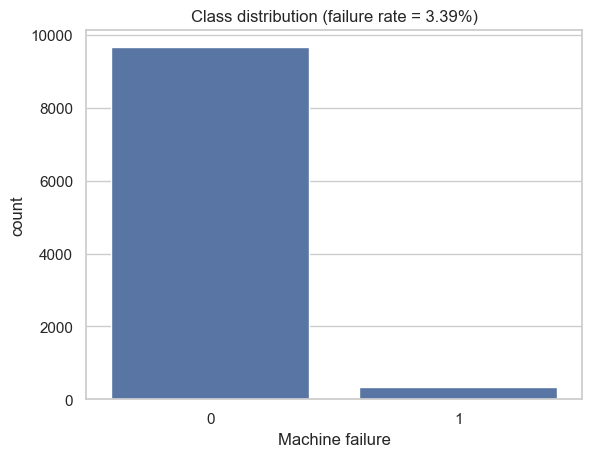

In [20]:
rate = df["Machine failure"].mean()
print(f"Failure rate: {rate:.2%}")

sns.countplot(x="Machine failure", data=df)
plt.title(f"Class distribution (failure rate = {rate:.2%})")
plt.show()

This number(3.39%) is the most important fact.

## 4. Target rate by product type

In [21]:
pd.crosstab(df["Type"], df["Machine failure"], normalize="index")

Machine failure,0,1
Type,,
H,0.979063,0.020937
L,0.960833,0.039167
M,0.972306,0.027694


Type L/M/H (low/medium/high quality variant). We have to check whether failure rate differs meaningfully by type. This matters because overstrain_failures threshold is literally defined differently per type.

## 5. Distributions(continuous sensors)

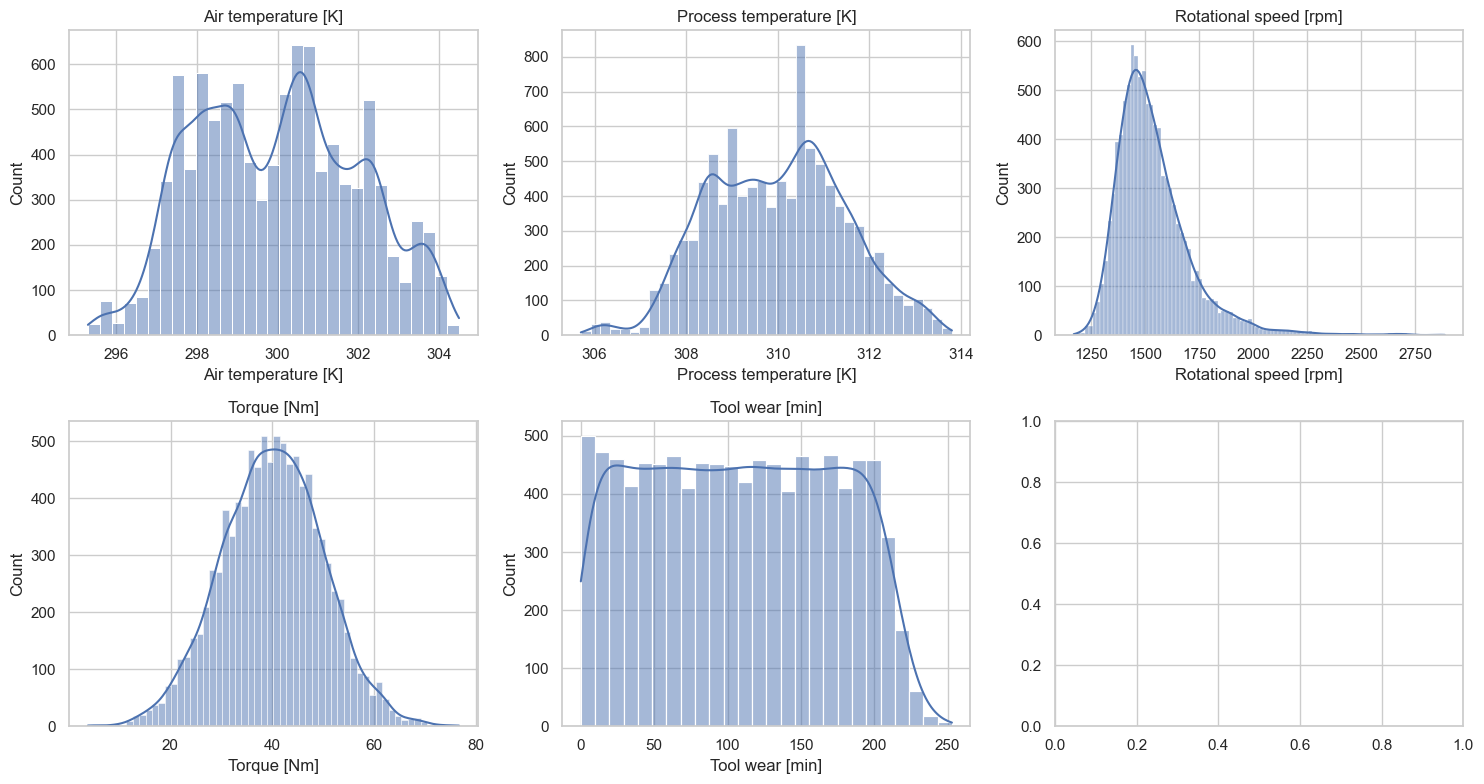

In [22]:
num_cols =["Air temperature [K]", "Process temperature [K]",
            "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]

fig, axes = plt.subplots(2,3, figsize=(15,8))
for ax , col in zip(axes.flat, num_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

Rotational speed is right-skewed.
Torque roughly normal.
Tool wear roughly uniform

## 6. Sensor distribution split by failure

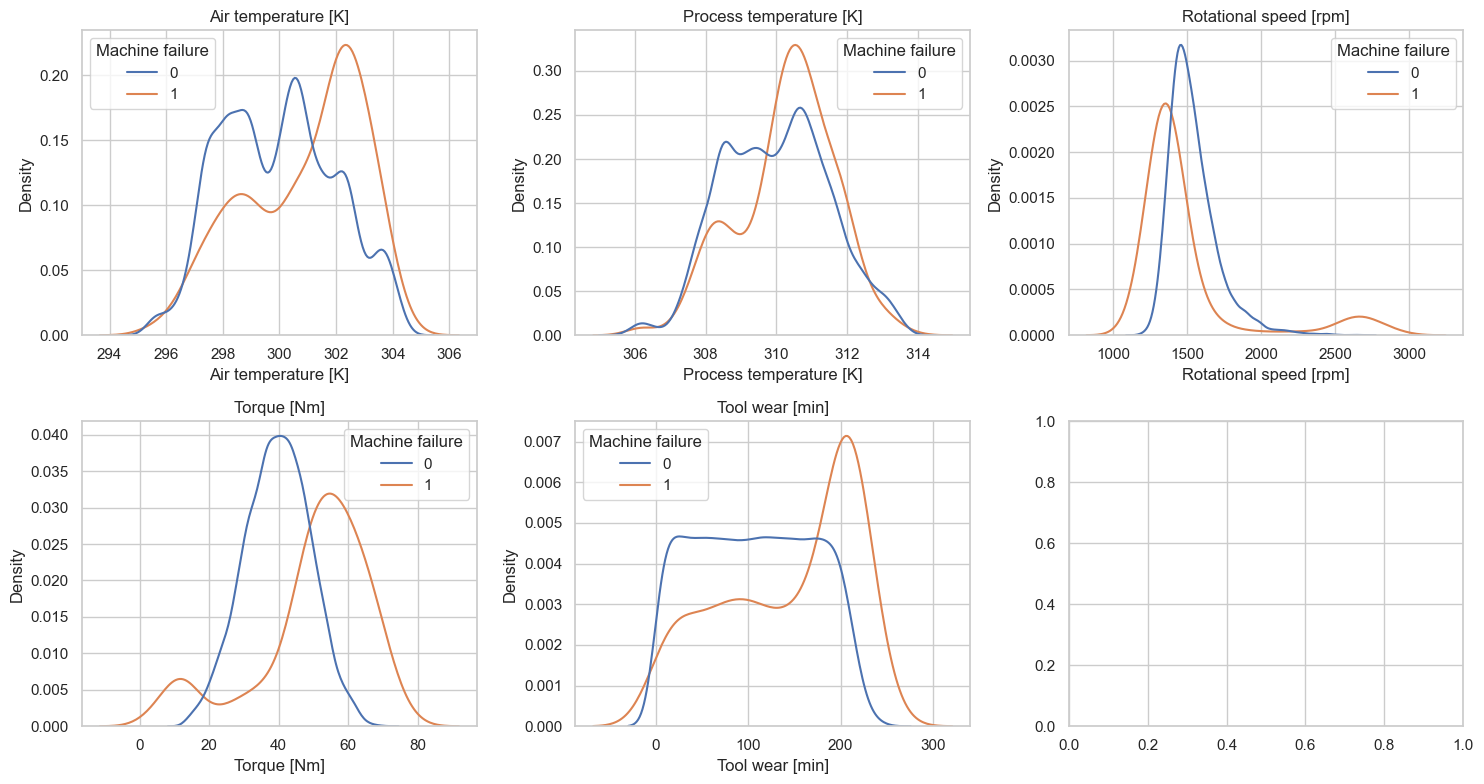

In [13]:
fig, axes = plt.subplots(2, 3 , figsize=(15,8))
for ax , col in zip(axes.flat, num_cols):
    sns.kdeplot(data=df, x=col, hue="Machine failure", ax=ax, common_norm=False)
    ax.set_title(col)
plt.tight_layout()
plt.show()

common_norm=False normalizes each class'e curve independently so the tinf failures class is not flattened to invisible. 
Torque and tool wear are showing visibly sifferent shapes for failures(that;s the overstrain, I was takling aboutmentioned above)

## Data Preparation

In [2]:
import sys
sys.path.insert(0, "..")

from src.data_prep import load_raw_data, engineer_features

df = load_raw_data("../data/raw/ai4i2020.csv")
df = engineer_features(df)
import sys
sys.path.append("..")

df = load_raw_data("../data/raw/ai4i2020.csv")
df= engineer_features(df)

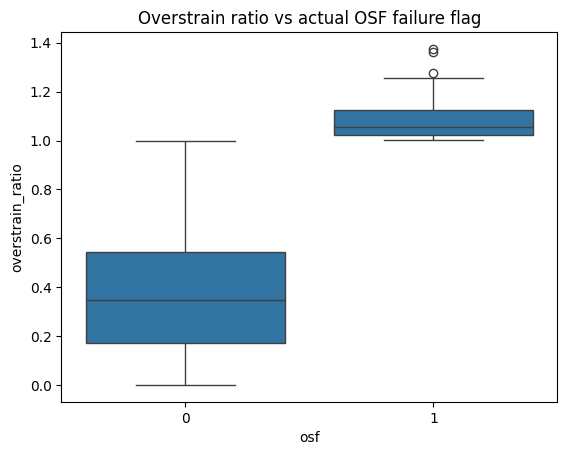

In [5]:
sns.boxplot(data=df, x="osf", y="overstrain_ratio")
plt.title("Overstrain ratio vs actual OSF failure flag")
plt.show()

 OSF is clearly sitting higher than overstrain_ratio.There is clear separation between them. It confirms overstrain_ratio is a genuinely predictive, not just noise.

## Pipeline

In [20]:
from src.data_prep import get_model_frame
from src.pipeline import build_preprocessor, split_data

df = load_raw_data("../data/raw/ai4i2020.csv")
df = engineer_features(df)
df = df.rename(columns={"UDI": "uid"})
X, y = get_model_frame(df)
X_train, X_test, y_train, y_test = split_data(X,y)

print("Train shape:", X_train.shape,"| Failure rate:", y_train.mean().round(4))
print("Test shape:", X_test.shape,"| Failure rate:", y_test.mean().round(4))

preprocessor = build_preprocessor()
X_train_transformed = preprocessor.fit_transform(X_train)
print("Transformed train shape:", X_train_transformed.shape)

Train shape: (8000, 12) | Failure rate: 0.0339
Test shape: (2000, 12) | Failure rate: 0.034
Transformed train shape: (8000, 16)
